# 7 · Reading a run

`results.tsv` is the loop's memory and your audit trail. This chapter shows how
to read one: which changes were kept, how the worst slice moved, and how to spot
the moment a different slice became the bottleneck.

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))   # make `harness` importable
import matplotlib
matplotlib.use("Agg")
import numpy as np
import matplotlib.pyplot as plt

from harness.data import make_synthetic_dataset, DatasetSpec, load_split, class_names

DATA = Path("../data/bdd-tiny.lance")
if not DATA.exists():
    print("building a small bdd-tiny ...")
    make_synthetic_dataset(DATA, DatasetSpec(n=3000, seed=7))
print("dataset:", DATA)

dataset: ../data/bdd-tiny.lance


In [2]:
from harness.loop import run_loop
run_loop(iters=8, dataset_path=str(DATA), results_path="results.tsv", verbose=False)
import pandas as pd
df = pd.read_csv("results.tsv", sep="\t")
df[["iter", "score", "best_so_far", "kept", "worst_group", "worst_group_name", "rationale"]]

,iter,score,best_so_far,kept,worst_group,worst_group_name,rationale
0,0,0.8835,0.8835,True,0.6444,foggy,baseline config
1,1,0.9718,0.9718,True,0.7333,foggy,"Fog is the worst, rarest slice -> upweight fog..."
2,2,0.9745,0.9745,True,0.7333,foggy,Expand fog upweighting to LanceDB nearest neig...
3,3,1.0179,1.0179,True,0.7778,foggy,Give the net more capacity to fit the weak fog...
4,4,0.9512,1.0179,False,0.7111,foggy,Spend more of the budget on epochs to extract ...
5,5,1.0190,1.0190,True,0.7778,foggy,Add weight decay to denoise the high-variance ...
6,6,0.9740,1.0190,False,0.7333,foggy,Label smoothing to stop overconfidence on nois...
7,7,0.9285,1.0190,False,0.6889,foggy,"Horizontal flip: cheap, label-preserving augme..."
8,8,0.9740,1.0190,False,0.7333,foggy,Cosine LR decay for a cleaner final convergence.


### The story of the run

In [3]:
kept = df[df["kept"].astype(str) == "True"]
print("kept changes:")
for _, r in kept.iterrows():
    print(f"  iter {int(r['iter'])}: score {r['score']:.3f}  ({r['rationale']})")
print(f"\nbaseline {df.iloc[0]['score']:.3f} -> best {df['best_so_far'].max():.3f}")
print("worst slice was:", df["worst_group_name"].value_counts().to_dict())

kept changes:
  iter 0: score 0.883  (baseline config)
  iter 1: score 0.972  (Fog is the worst, rarest slice -> upweight fog frames 5x.)
  iter 2: score 0.975  (Expand fog upweighting to LanceDB nearest neighbours (fog-like frames).)
  iter 3: score 1.018  (Give the net more capacity to fit the weak fog signal.)
  iter 5: score 1.019  (Add weight decay to denoise the high-variance fog frames.)

baseline 0.883 -> best 1.019
worst slice was: {'foggy': 9}


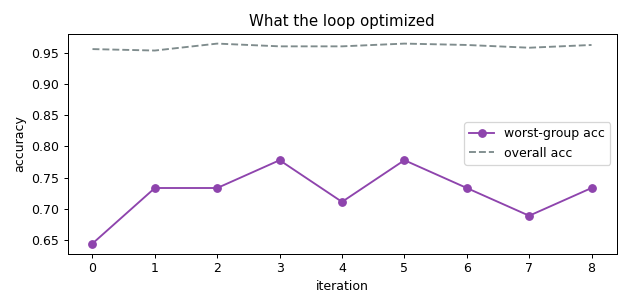

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(df["iter"], df["worst_group"], "-o", label="worst-group acc", color="#8e44ad")
ax.plot(df["iter"], df["overall_accuracy"], "--", label="overall acc", color="#7f8c8d")
ax.set_xlabel("iteration"); ax.set_ylabel("accuracy"); ax.set_title("What the loop optimized")
ax.legend(); fig.tight_layout(); fig.savefig("fig_07_run.png", dpi=90); plt.close(fig)
from IPython.display import Image; Image("fig_07_run.png")

That's the tiny tier end to end: a fixed task, an immutable scorer, a budgeted
training surface, mining, and a loop that keeps only what helps. From here the
book scales the *same contract* to bigger data and real distributed infra —
Daft pipelines, Ray Train, Ray Tune, FiftyOne, and finally an LLM in the loop
(Chapters 8-20).